# Block 03 - optical flow and extrapolation

Four motion methods on the last fields before the issue time (Lucas-Kanade on 4, VET on 3,
DARTS on 8 - the session's choices - and Proesmans on 2), each on dBR; then semi-Lagrangian
extrapolation, the simplest nowcast (Lagrangian persistence).

In [1]:
import sys
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from core import viz_style as vs
from os_nowcasting import data, grid, nowcast, plots, products, verify
vs.use_style()

In [2]:
NET, STEP = "openrainer", 15
radar = data.radar(NET, "2022-08-18 05:45", "2022-08-18 11:00")
rate, meta = grid.to_pysteps(radar, STEP)
times = pd.DatetimeIndex(radar.time.values)
ISSUE = times.get_loc(pd.Timestamp("2022-08-18 08:45"))
print(rate.shape, "pixels of", meta["xpixelsize"] / 1000, "km; issue time", times[ISSUE])

(22, 97, 155) pixels of 2.0000659081611216 km; issue time 2022-08-18 08:45:00


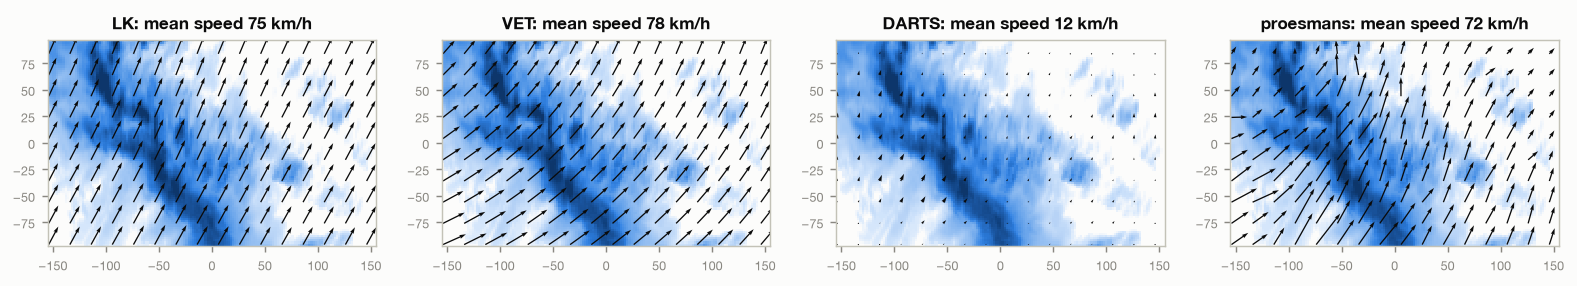

In [3]:
past = rate[:ISSUE + 1]
fig, axes = plt.subplots(1, 4, figsize=(15, 3.4))
V = {}
for ax, m in zip(axes, nowcast.MOTION_METHODS):
    V[m] = nowcast.motion(past, meta, m)
    plots.field(ax, past[-1], meta, f"{m}: mean speed {np.hypot(*V[m]).mean() * 2 * 4:.0f} km/h", vmax=30)
    plots.quiver(ax, V[m], meta, step=10)

LK and VET agree; DARTS, as the session found, gives a much weaker and rotating field on a
domain this size. Without the dB transform LK follows the strongest cells:

In [4]:
v_raw = nowcast.motion(past, meta, "LK", transform=False)
d = np.hypot(*(v_raw - V["LK"])) * 2 * 4
print(f"LK on rain rate vs LK on dBR: median vector difference {np.median(d):.1f} km/h")

LK on rain rate vs LK on dBR: median vector difference 5.7 km/h


## Extrapolation

Four steps (one hour) ahead, and at fractional steps (every minute) as needed for
accumulations.

(16, 97, 155) frames between the issue time and the next step


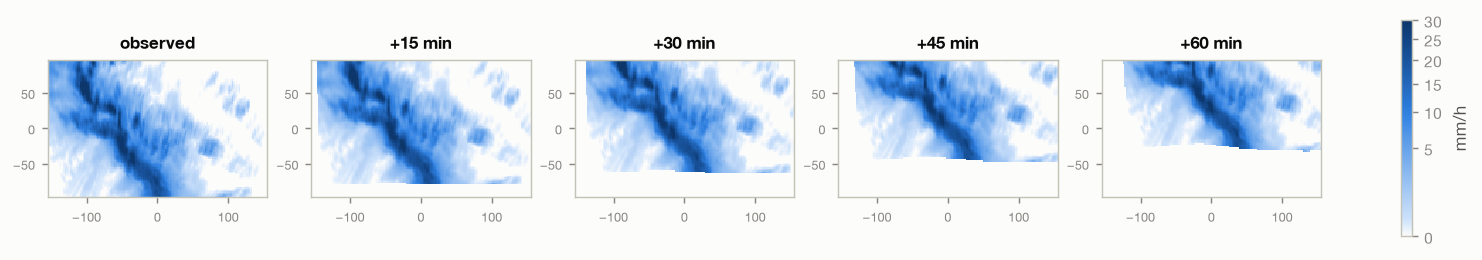

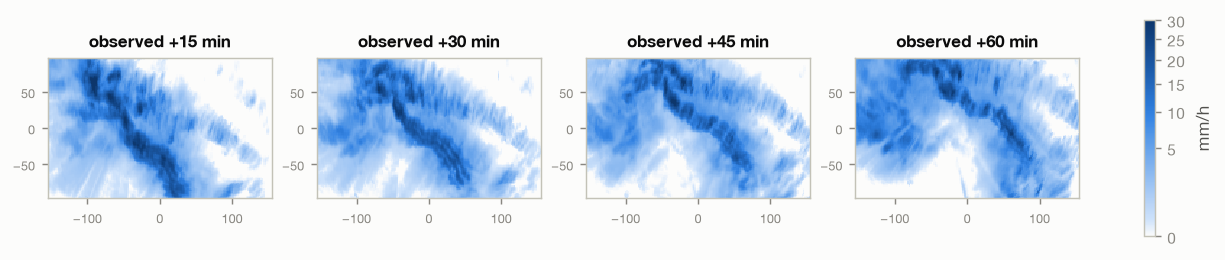

In [5]:
f = nowcast.extrapolate(past[-1], V["LK"], 4)
fig, axes = plots.row([past[-1]] + list(f), ["observed"] + [f"+{15 * (k + 1)} min" for k in range(4)], meta, vmax=30)
obs = rate[ISSUE + 1:ISSUE + 5]
fig, axes = plots.row(list(obs), [f"observed +{15 * (k + 1)} min" for k in range(4)], meta, vmax=30)
sub = nowcast.extrapolate(past[-1], V["LK"], np.linspace(0, 1, 16))
print(sub.shape, "frames between the issue time and the next step")

## Motion from link maps

Can the link maps carry the motion? LK on the IDW-40 km map and on the merged field, against
the radar's motion over wet cells (the study does this at every issue time).

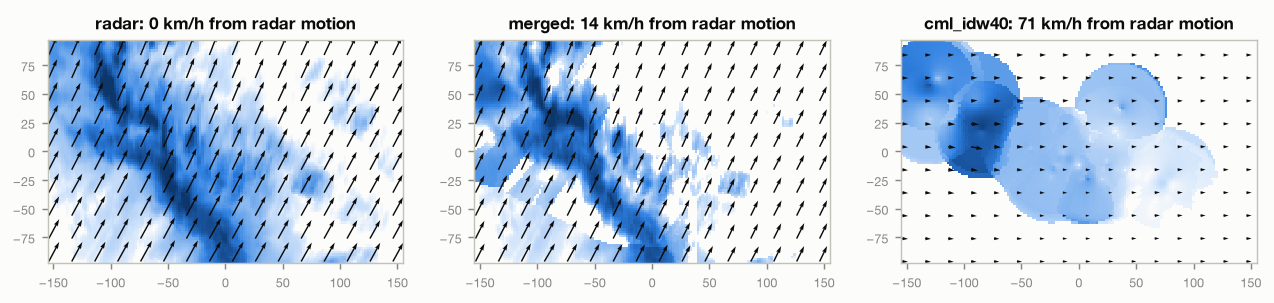

In [6]:
prods = products.build(NET, radar.time.values[0], radar.time.values[-1], radar)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for ax, k in zip(axes, ["radar", "merged", "cml_idw40"]):
    r = grid.to_pysteps(prods[k], STEP)[0][:ISSUE + 1]
    v = nowcast.motion(r, meta, "LK")
    wet = past[-1] > 0.1
    plots.field(ax, r[-1], meta, f"{k}: {np.hypot(*(v - V['LK']))[wet].mean() * 8:.0f} km/h from radar motion", vmax=30)
    plots.quiver(ax, v, meta, step=10)